In [2]:
# Import libraries
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import exp1
from scipy.fft import fft,ifft,fft2, ifft2, fftfreq, fftshift, ifftshift
from scipy.interpolate import griddata

# Given constants
xc = 0.5
yc = 0.5
sigma = 0.05


# Define functions
def rho(x, y):
    C = 2*np.pi*sigma**2
    arg = -1/(2*sigma**2) * ((x - xc)**2 + (y - yc)**2)
    return 1/C * np.exp(arg)

def G(x, y):
    return -1/(4*np.pi) * np.log( x**2 + y**2 + h**2 )

def inf_norm(Vh, V):
    errs = np.abs(Vh - V)
    return np.max(errs)

def exact_soln(x,y,N,h):
    V0 = np.zeros([N,N])
    arg = ( (x - xc)**2 + (y - yc)**2 + h**2)/(2*sigma**2)
    V0 = -1/(4*np.pi) * ( exp1(arg) + np.log( (x - xc)**2 + (y - yc)**2 + h**2) )
    return V0

def direct_integration(X,Y,N,h):
    V1 = np.zeros_like(X)
    
    rho_vals = rho(X,Y)

    for i in range(N):
        for j in range(N):
            V1[i,j] = np.sum( rho_vals * G(x[i]-X,y[j]-Y) )

    V1 = V1 * h**2
    return V1

def fourier_method(X,Y,N,h):
    V2 = np.zeros([2*N,2*N])
    V2_hat = np.zeros([2*N,2*N])
    rho_vals = np.zeros([2*N,2*N])
    G_vals = np.zeros([2*N,2*N])

    x_fft = fftfreq(2*N,h)
    y_fft = x_fft

    rho_vals[:N,:N] = rho(X,Y)
    rho_hat = fft2(rho_vals)
    
    xp = np.arange(-N,N) * h
    yp = xp
    Xp,Yp = np.meshgrid(xp,yp, indexing='ij')

    G_vals = G(Xp,Yp)
    #G_vals[N,N] = 0.
    G_hat = fft2(ifftshift(G_vals))

    V2_hat = rho_hat * G_hat
    V2 = ifft2(V2_hat) * h**2
    V2 = np.real(V2)
    
    x_fft = fftshift(x_fft)
    y_fft = fftshift(y_fft)

    x_ = (x_fft - x_fft.min()) / (x_fft.max() - x_fft.min()) * 2
    y_ = (y_fft - y_fft.min()) / (y_fft.max() - y_fft.min()) * 2
    
    return x_, y_, V2


In [3]:
# Compare direct integration to Fourier method

Ns = [2**i for i in np.arange(3,8,1)]

V1_errs = np.zeros(len(Ns), dtype=float)
V2_errs = np.zeros(len(Ns), dtype=float)

V1_times = np.zeros(len(Ns), dtype=float)
V2_times = np.zeros(len(Ns), dtype=float)

for i in range(len(Ns)):
    N = Ns[i]
    h = 1/N
    x = np.linspace(0,1,N)
    y = np.linspace(0,1,N)
    X,Y = np.meshgrid(x,y, indexing='ij')
    
    # Compute exact solution
    V0 = exact_soln(X,Y,N,h)
    
    # Perform direct integration and record run time
    s = time.time()
    V1 = direct_integration(X,Y,N,h)
    V1_times[i] = time.time() - s
    
    # Perform Fourier method and record run time
    s = time.time()
    x_,y_,V2 = fourier_method(X,Y,N,h)
    V2_times[i] = time.time() - s
    
    # Interpolate V2 onto grid used to compute exact solution
    X_, Y_ = np.meshgrid(x_,y_, indexing='ij')
    V2_int = griddata((X_.ravel(),Y_.ravel()), V2.ravel(), (X.ravel(),Y.ravel()), method='cubic')
    V2_int = np.reshape(V2_int, (N,N))
    
    # Record errors
    V1_errs[i] = inf_norm(V1,V0)
    V2_errs[i] = inf_norm(V2[:N,:N],V0)

print('Process complete.')

Process complete.


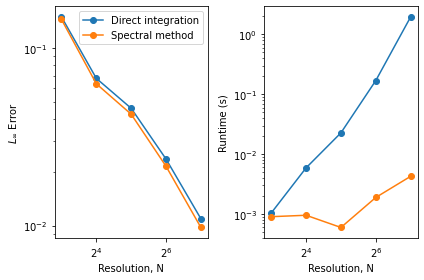

In [7]:
fig, (ax1, ax2) = plt.subplots(1,2)

ax1.set_xscale('log', base=2)
ax1.set_yscale('log', base=10)
ax1.plot(Ns,V1_errs, '-o', label='Direct integration')
ax1.plot(Ns,V2_errs, '-o', label='Spectral method')
ax1.set_xlabel('Resolution, N')
ax1.set_ylabel(r'$L_\infty$ Error')
ax1.legend()

ax2.set_xscale('log', base=2)
ax2.set_yscale('log', base=10)
ax2.plot(Ns,V1_times,'-o')
ax2.plot(Ns,V2_times,'-o')
ax2.set_xlabel('Resolution, N')
ax2.set_ylabel('Runtime (s)')

fig.tight_layout()
#fig.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3, ncol=2, borderaxespad=0.)

plt.savefig('p1c.png')
plt.show()